# Twitter Sentiment Analysis Mental Health Topic
### Gabungan: 01_data_wrangling | 02_eda | 03_ab_testing

## Install & Imports

In [2]:
# Install library tambahan jika diperlukan
# !pip install openpyxl scipy

import ast
import json
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, shapiro

warnings.filterwarnings('ignore')
print(' Import selesai')

 Import selesai


##  Konfigurasi Path & Tema

In [3]:
# Konfigurasi Path
# Jika pakai Google Colab, upload file Excel terlebih dahulu atau mount Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# RAW_PATH = Path('/content/drive/MyDrive/Twitter_Analysis.xlsx')

RAW_PATH      = Path('Twitter_Analysis.xlsx')
PROCESSED_DIR = Path('processed')
OUTPUT_DIR    = Path('figures')

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {2: 'Positive', 1: 'Neutral', 0: 'Negative'}
ALPHA     = 0.05

PAL = {'Positive': '#00C896', 'Neutral': '#4A9EFF', 'Negative': '#FF5A5A'}
THEME = {
    'BG'  : '#0D1117',
    'CARD': '#161B22',
    'GRID': '#21262D',
    'TXT' : '#E6EDF3',
    'SUB' : '#8B949E',
    'YEL' : '#F0C040',
}

plt.rcParams.update({
    'figure.facecolor' : THEME['BG'],
    'axes.facecolor'   : THEME['CARD'],
    'axes.edgecolor'   : THEME['GRID'],
    'text.color'       : THEME['TXT'],
    'xtick.color'      : THEME['SUB'],
    'ytick.color'      : THEME['SUB'],
    'grid.color'       : THEME['GRID'],
    'axes.labelcolor'  : THEME['TXT'],
    'axes.titlecolor'  : THEME['TXT'],
    'legend.facecolor' : THEME['CARD'],
    'legend.edgecolor' : THEME['GRID'],
    'legend.labelcolor': THEME['TXT'],
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 10,
})

print(' Konfigurasi selesai')

 Konfigurasi selesai


## Helper Functions

In [4]:
def clean_text(text: str) -> str:
    """Hapus URL dan normalisasi whitespace dari teks tweet."""
    text = str(text).strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def parse_hashtags(raw: str) -> list:
    """
    Konversi string representasi list ke Python list.
    Input  : "['Stress', 'anxiety']"
    Output : ['stress', 'anxiety']
    """
    try:
        items = ast.literal_eval(str(raw))
        return [
            re.sub(r"['\"\s#]", '', str(item)).lower().strip()
            for item in items
            if len(str(item).strip()) > 1
        ]
    except Exception:
        return []


def format_pvalue(p: float) -> str:
    """Format p-value: tampilkan 6 desimal atau '< 0.0001' jika sangat kecil."""
    return f'{p:.6f}' if p >= 0.0001 else '< 0.0001'


def is_significant(p: float, alpha: float = ALPHA) -> str:
    """Kembalikan label keputusan uji hipotesis."""
    return (
        f'✅ SIGNIFIKAN → Tolak H\u2080 (p={format_pvalue(p)})'
        if p < alpha
        else f' Tidak Signifikan → Gagal Tolak H\u2080 (p={format_pvalue(p)})'
    )


def save_figure(fig: plt.Figure, name: str) -> None:
    """Simpan figure ke OUTPUT_DIR dengan format PNG."""
    path = OUTPUT_DIR / f'{name}.png'
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor=THEME['BG'])
    plt.show()
    plt.close(fig)
    print(f'✅ Disimpan → {path}')


print(' Helper functions siap')

 Helper functions siap


# BAGIAN 1 DATA WRANGLING
> Pipeline: Gathering → Assessing → Cleaning → Feature Engineering

### 1. Gathering Data

In [5]:
# Dataset: tweet bertema Mental Health dengan label sentimen manual
# Label: Bagus (2=Positive) | Cukup (1=Neutral) | Buruk (0=Negative)

try:
    df_raw = pd.read_excel(RAW_PATH)
    print(f'Dataset dimuat: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
except FileNotFoundError:
    raise SystemExit(
        f'[ERROR] File tidak ditemukan: {RAW_PATH}\n'
        'Pastikan file Excel sudah diupload ke Colab.'
    )

Dataset dimuat: 12,492 baris × 6 kolom


### 2. Assessing Data

In [6]:
# 2.1 Dimensi & Tipe Data
print(f'Shape  : {df_raw.shape}')
print(f'Kolom  : {df_raw.columns.tolist()}\n')
df_raw.dtypes

Shape  : (12492, 6)
Kolom  : ['text', 'hashtags', 'labels', 'label_text', 'text_length', 'hashtag_count']



text             object
hashtags         object
labels            int64
label_text       object
text_length       int64
hashtag_count     int64
dtype: object

In [7]:
# 2.2 Missing Values
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
text,0,0.0
hashtags,0,0.0
labels,0,0.0
label_text,0,0.0
text_length,0,0.0
hashtag_count,0,0.0


In [8]:
# 2.3 Duplikat
n_dup_full = df_raw.duplicated().sum()
n_dup_text = df_raw.duplicated(subset=['text']).sum()

print(f'Duplikat baris penuh  : {n_dup_full:,} ({n_dup_full / len(df_raw) * 100:.1f}%)')
print(f"Duplikat kolom 'text' : {n_dup_text:,} ({n_dup_text / len(df_raw) * 100:.1f}%)")

Duplikat baris penuh  : 3,907 (31.3%)
Duplikat kolom 'text' : 4,053 (32.4%)


In [9]:
# 2.4 Distribusi Kelas & Statistik Deskriptif
print('Distribusi label (raw):')
print(df_raw['label_text'].value_counts().to_string())
print()
df_raw[['text_length', 'hashtag_count']].describe().round(2)

Distribusi label (raw):
label_text
Bagus    4164
Cukup    4164
Buruk    4164



,text_length,hashtag_count
count,12492.00,12492.00
mean,180.81,4.32
std,73.88,4.96
min,11.00,0.00
25%,121.00,1.00
50%,193.00,3.00
75%,240.00,6.00
max,1019.00,30.00


In [10]:
# Simpan laporan assessment ke JSON
dist_raw          = df_raw['label_text'].value_counts()
assessment_report = {
    'total_rows_raw'    : int(len(df_raw)),
    'total_cols'        : int(len(df_raw.columns)),
    'missing_values'    : {k: int(v) for k, v in missing.items()},
    'duplicate_rows'    : int(n_dup_full),
    'duplicate_text'    : int(n_dup_text),
    'class_distribution': {k: int(v) for k, v in dist_raw.items()},
    'text_length_mean'  : float(df_raw['text_length'].mean()),
    'text_length_max'   : float(df_raw['text_length'].max()),
    'hashtag_count_mean': float(df_raw['hashtag_count'].mean()),
}
out_path = PROCESSED_DIR / 'assessment.json'
with open(out_path, 'w') as f:
    json.dump(assessment_report, f, indent=2)
print(f' Laporan assessment disimpan → {out_path}')

 Laporan assessment disimpan → processed\assessment.json


### 3. Cleaning Data

In [11]:
# 3.1 Deduplikasi berdasarkan kolom 'text'
df      = df_raw.drop_duplicates(subset=['text']).copy().reset_index(drop=True)
removed = len(df_raw) - len(df)

print(f'Sebelum : {len(df_raw):,} baris')
print(f'Dihapus : {removed:,} duplikat ({removed / len(df_raw) * 100:.1f}%)')
print(f'Sesudah : {len(df):,} baris')

Sebelum : 12,492 baris
Dihapus : 4,053 duplikat (32.4%)
Sesudah : 8,439 baris


In [12]:
# 3.2 Pembersihan Teks: hapus URL dan normalisasi whitespace
df['text_clean'] = df['text'].apply(clean_text)

n_with_url = df['text'].str.contains(r'http\S+|www\S+', regex=True).sum()
print(f'Tweet dengan URL (sebelum dibersihkan): {n_with_url:,}')
print('✅ URL dan whitespace berlebih berhasil dibersihkan')

Tweet dengan URL (sebelum dibersihkan): 0
✅ URL dan whitespace berlebih berhasil dibersihkan


In [13]:
# 3.3 Parsing Hashtag: dari string repr Python list → Python list sesungguhnya
df['hashtag_list'] = df['hashtags'].apply(parse_hashtags)

print('Contoh hasil parsing hashtag:')
for i in range(3):
    print(f'  [{i}] {df["hashtag_list"].iloc[i]}')

Contoh hasil parsing hashtag:
  [0] ['stress', 'infertility', 'lifestylefactors', 'fertility', 'uscfertility']
  [1] ['stress']
  [2] ['churchmentalhealth', 'mentalhealthmatters', 'cmhs21']


In [14]:
# 3.4 Feature Engineering
df['word_count']        = df['text_clean'].str.split().str.len()
df['text_length_clean'] = df['text_clean'].str.len()
df['avg_word_len']      = df['text_clean'].apply(
    lambda x: round(np.mean([len(w) for w in x.split()]), 3) if x.split() else 0.0
)
df['hashtag_density']   = (df['hashtag_count'] / (df['word_count'] + 1)).round(4)
df['char_per_word']     = (df['text_length_clean'] / (df['word_count'] + 1)).round(3)
df['exclaim_count']     = df['text'].str.count('!')
df['question_count']    = df['text'].str.count(r'\?')
df['caps_ratio']        = df['text'].apply(
    lambda x: round(sum(c.isupper() for c in x) / max(len(x), 1), 4)
)
df['has_hashtag']       = df['hashtag_count'] > 0
df['has_mention']       = df['text'].str.contains(r'@\w+', regex=True)
df['has_url']           = df['text'].str.contains(r'http\S+|www\S+', regex=True)
df['label_text']        = df['labels'].map(LABEL_MAP)

new_features = [
    'word_count', 'text_length_clean', 'avg_word_len',
    'hashtag_density', 'char_per_word', 'exclaim_count',
    'question_count', 'caps_ratio', 'has_hashtag',
    'has_mention', 'has_url', 'label_text',
]
print(f'✅ {len(new_features)} fitur baru ditambahkan:')
for feat in new_features:
    print(f'   + {feat}')

✅ 12 fitur baru ditambahkan:
   + word_count
   + text_length_clean
   + avg_word_len
   + hashtag_density
   + char_per_word
   + exclaim_count
   + question_count
   + caps_ratio
   + has_hashtag
   + has_mention
   + has_url
   + label_text


In [15]:
# 3.5 Validasi Pasca-Cleaning
print(f'Shape akhir      : {df.shape}')
print(f'Missing values   : {df.isnull().sum().sum()}')
print(f'Duplikat tersisa : {df.duplicated(subset=["text"]).sum()}')
print(f'Kolom final      : {df.columns.tolist()}')

Shape akhir      : (8439, 19)
Missing values   : 0
Duplikat tersisa : 0
Kolom final      : ['text', 'hashtags', 'labels', 'label_text', 'text_length', 'hashtag_count', 'text_clean', 'hashtag_list', 'word_count', 'text_length_clean', 'avg_word_len', 'hashtag_density', 'char_per_word', 'exclaim_count', 'question_count', 'caps_ratio', 'has_hashtag', 'has_mention', 'has_url']


In [16]:
# Simpan dataset bersih
df_to_save = df.drop(columns=['hashtag_list'])
clean_path = PROCESSED_DIR / 'twitter_clean.csv'
df_to_save.to_csv(clean_path, index=False)

print(f'Dataset bersih disimpan  {clean_path}')
print(f'   {len(df_to_save):,} baris × {len(df_to_save.columns)} kolom')

Dataset bersih disimpan  processed\twitter_clean.csv
   8,439 baris × 18 kolom


In [17]:
# Simpan top 20 hashtag per sentimen
top_hashtags: dict = {}
for sentiment in ['Positive', 'Neutral', 'Negative']:
    all_tags = [
        tag
        for tag_list in df[df['label_text'] == sentiment]['hashtag_list']
        for tag in tag_list
    ]
    top_hashtags[sentiment] = [
        [tag, int(count)]
        for tag, count in Counter(all_tags).most_common(20)
    ]

hashtag_path = PROCESSED_DIR / 'top_hashtags.json'
with open(hashtag_path, 'w') as f:
    json.dump(top_hashtags, f, indent=2)

print(f' Top hashtags disimpan {hashtag_path}')
for sentiment in ['Positive', 'Neutral', 'Negative']:
    print(f'   {sentiment:<10} top-3: {top_hashtags[sentiment][:3]}')

 Top hashtags disimpan processed\top_hashtags.json
   Positive   top-3: [['mentalhealth', 415], ['stress', 331], ['mentalhealthmatters', 202]]
   Neutral    top-3: [['mentalhealth', 771], ['stress', 652], ['mentalhealthmatters', 406]]
   Negative   top-3: [['happy', 1012], ['excited', 757], ['mentalhealth', 558]]


### Business Questions

1. Apakah distribusi sentimen seimbang? *(Descriptive Stats)*
2. Hashtag apa yang paling dominan per sentimen? *(Word Frequency)*
3. Apakah jumlah hashtag berbeda antar sentimen? *(Mann-Whitney U)*
4. Apakah panjang teks berbeda antar sentimen? *(Kruskal-Wallis)*
5. Adakah pola ironi dalam penggunaan kata? *(Analisis Hashtag)*

#  BAGIAN 2 EDA (Exploratory Data Analysis)
> Section 5: Statistik Deskriptif | Section 6: Visualisasi (Viz 1–3)

In [18]:
# Load data (dari hasil cleaning Bagian 1)
pos = df[df['label_text'] == 'Positive']
neu = df[df['label_text'] == 'Neutral']
neg = df[df['label_text'] == 'Negative']

print(f' Dataset: {len(df):,} baris × {len(df.columns)} kolom')
print(f' Positive: {len(pos):,} | Neutral: {len(neu):,} | Negative: {len(neg):,}')

 Dataset: 8,439 baris × 19 kolom
 Positive: 1,505 | Neutral: 2,804 | Negative: 4,130


### 5. Exploratory Data Analysis

In [19]:
# 5.1 Distribusi Sentimen (Pasca Cleaning)
dist = df['label_text'].value_counts()
for sentiment, count in dist.items():
    bar = '█' * int(count / 50)
    print(f'  {sentiment:<10} {count:>5,}  ({count / len(df) * 100:.1f}%)  {bar}')

  Negative   4,130  (48.9%)  ██████████████████████████████████████████████████████████████████████████████████
  Neutral    2,804  (33.2%)  ████████████████████████████████████████████████████████
  Positive   1,505  (17.8%)  ██████████████████████████████


In [20]:
# 5.2 Statistik Deskriptif per Sentimen
feature_cols = ['word_count', 'text_length_clean', 'hashtag_count', 'hashtag_density', 'avg_word_len']
df.groupby('label_text')[feature_cols].agg(['mean', 'median', 'std']).round(3)

word_count                text_length_clean                 \
                 mean median     std              mean median     std   
label_text                                                              
Negative       27.269   28.0  12.218           181.277  193.0  77.083   
Neutral        26.812   27.0  11.947           178.536  190.0  72.778   
Positive       27.025   27.0  12.186           179.385  190.0  72.803   

           hashtag_count               hashtag_density                \
                    mean median    std            mean median    std   
label_text                                                             
Negative           5.247    3.0  5.957           0.208  0.138  0.206   
Neutral            3.740    3.0  4.136           0.164  0.111  0.168   
Positive           3.728    3.0  4.153           0.164  0.111  0.168   

           avg_word_len                
                   mean median    std  
label_text                             
Negative          5.840  5.595  1.288  
Neutral           5.914  5.625  1.371  
Positive          5.920  5.647  1.372

In [21]:
# 5.3 Persentase Fitur Boolean per Sentimen
bool_cols = ['has_hashtag', 'has_mention', 'has_url']
for col in bool_cols:
    print(f'\n{col}:')
    for sentiment in ['Positive', 'Neutral', 'Negative']:
        pct = df[df['label_text'] == sentiment][col].mean() * 100
        print(f'  {sentiment:<10} {pct:.1f}%')


has_hashtag:
  Positive   82.9%
  Neutral    84.3%
  Negative   87.5%

has_mention:
  Positive   0.0%
  Neutral    0.0%
  Negative   0.0%

has_url:
  Positive   0.0%
  Neutral    0.0%
  Negative   0.0%


In [22]:
# 5.4 Korelasi Fitur Numerik dengan Target
numeric_cols = [
    'text_length_clean', 'word_count', 'hashtag_count',
    'hashtag_density', 'avg_word_len', 'char_per_word',
    'exclaim_count', 'question_count', 'labels',
]
corr = df[numeric_cols].corr()['labels'].drop('labels').sort_values(ascending=False)
print('Korelasi fitur dengan target (labels):')
for feat, val in corr.items():
    bar = '+' * int(abs(val) * 20) if val > 0 else '-' * int(abs(val) * 20)
    print(f'  {feat:<22} {val:+.4f}  {bar}')

Korelasi fitur dengan target (labels):
  question_count         +0.0534  +
  avg_word_len           +0.0261  
  char_per_word          +0.0247  
  word_count             -0.0114  
  text_length_clean      -0.0128  
  hashtag_density        -0.1051  --
  exclaim_count          -0.1141  --
  hashtag_count          -0.1309  --


In [23]:
# 5.5 Top 5 Hashtag per Sentimen
for sentiment in ['Positive', 'Neutral', 'Negative']:
    print(f'\nSentimen {sentiment}:')
    for tag, count in top_hashtags[sentiment][:5]:
        bar = '█' * int(count / 30)
        print(f'  #{tag:<30} {count:>5,}  {bar}')


Sentimen Positive:
  #mentalhealth                     415  █████████████
  #stress                           331  ███████████
  #mentalhealthmatters              202  ██████
  #tired                            173  █████
  #anxiety                          110  ███

Sentimen Neutral:
  #mentalhealth                     771  █████████████████████████
  #stress                           652  █████████████████████
  #mentalhealthmatters              406  █████████████
  #tired                            295  █████████
  #anxiety                          210  ███████

Sentimen Negative:
  #happy                          1,012  █████████████████████████████████
  #excited                          757  █████████████████████████
  #mentalhealth                     558  ██████████████████
  #stress                           547  ██████████████████
  #love                             378  ████████████


### 6. Visualisasi Data

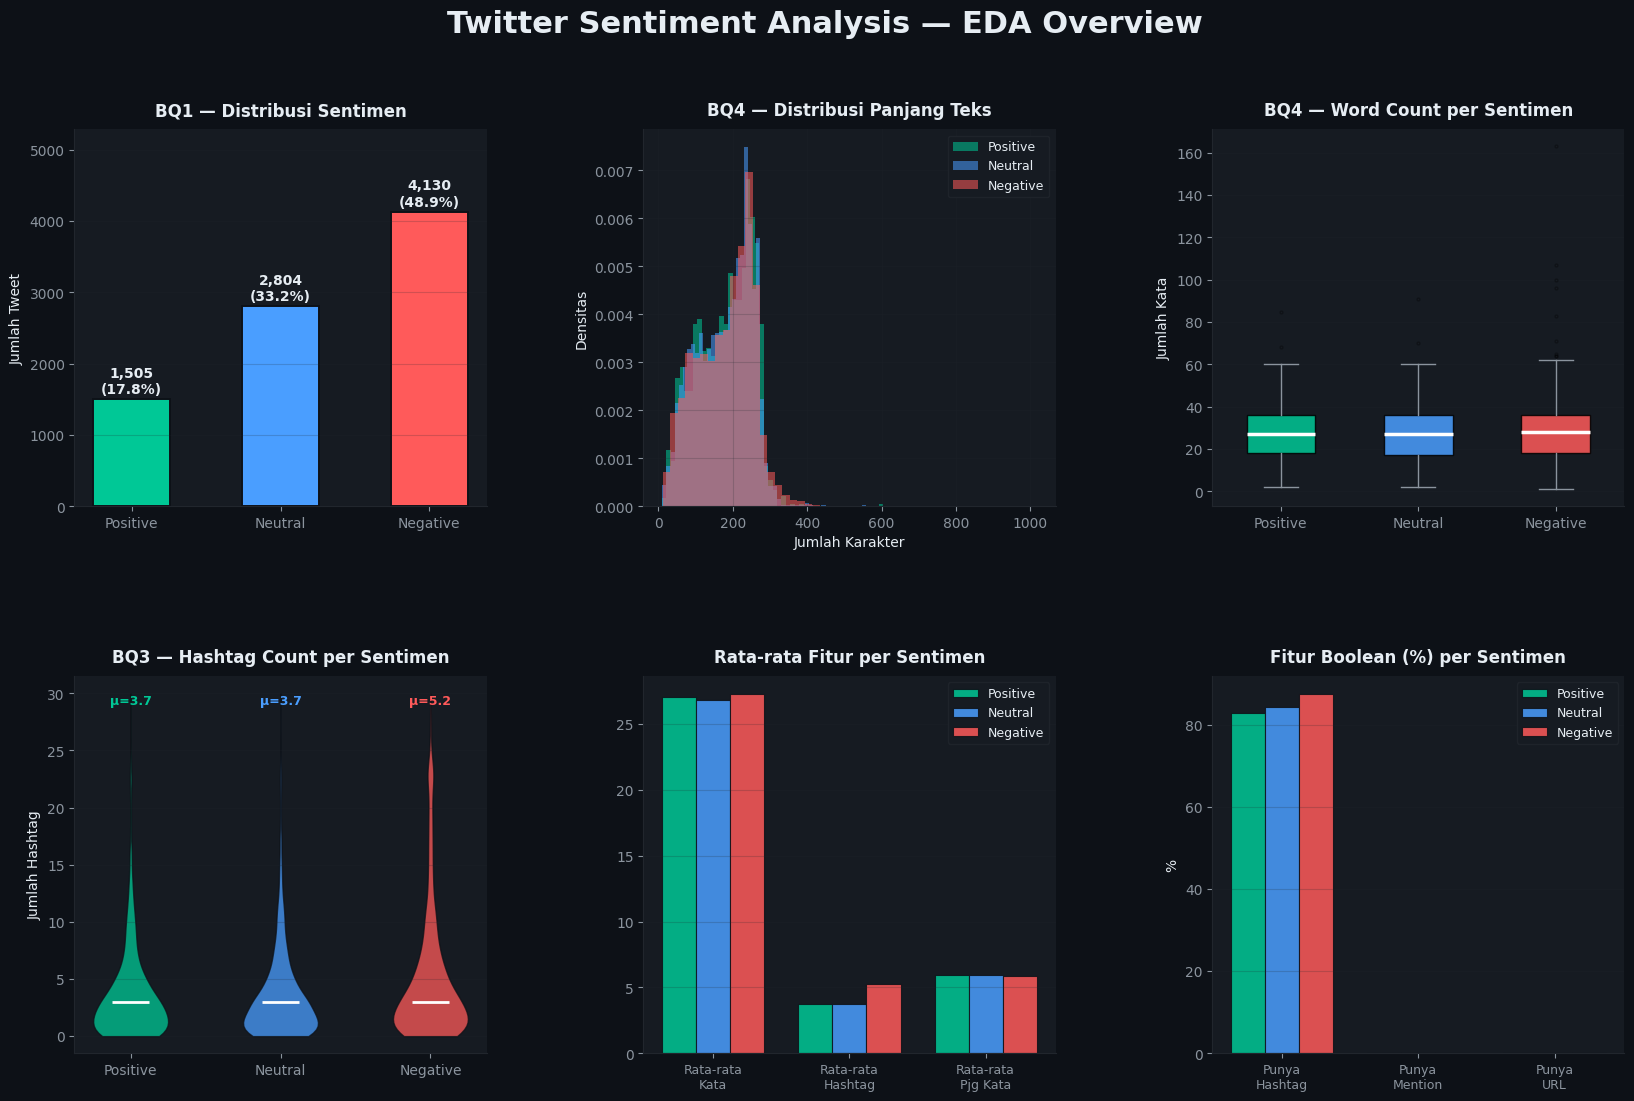

✅ Disimpan → figures\viz1_eda_overview.png


In [24]:
# Viz 1 EDA Overview Dashboard (2×3 grid)
BG = THEME['BG']; CARD = THEME['CARD']; GRID_C = THEME['GRID']
TXT = THEME['TXT']; SUB = THEME['SUB']

fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle('Twitter Sentiment Analysis — EDA Overview',
             fontsize=22, fontweight='bold', color=TXT, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel A: Distribusi Sentimen (BQ1)
ax_a   = fig.add_subplot(gs[0, 0])
counts = df['label_text'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
bars   = ax_a.bar(counts.index, counts.values,
                  color=[PAL[s] for s in counts.index], width=0.52, edgecolor=BG, linewidth=1.4)
for bar in bars:
    h = bar.get_height()
    ax_a.text(bar.get_x() + bar.get_width() / 2, h + 40,
              f'{int(h):,}\n({h / len(df) * 100:.1f}%)',
              ha='center', va='bottom', fontsize=10, fontweight='bold', color=TXT)
ax_a.set_title('BQ1 — Distribusi Sentimen')
ax_a.set_ylabel('Jumlah Tweet')
ax_a.set_ylim(0, counts.max() * 1.28)
ax_a.grid(axis='y', alpha=0.2)

# Panel B: Distribusi Panjang Teks (BQ4)
ax_b = fig.add_subplot(gs[0, 1])
for sentiment in ['Positive', 'Neutral', 'Negative']:
    vals = df[df['label_text'] == sentiment]['text_length_clean']
    ax_b.hist(vals, bins=50, alpha=0.55, color=PAL[sentiment], label=sentiment, density=True)
ax_b.set_title('BQ4 — Distribusi Panjang Teks')
ax_b.set_xlabel('Jumlah Karakter')
ax_b.set_ylabel('Densitas')
ax_b.legend(fontsize=9)
ax_b.grid(alpha=0.2)

# Panel C: Word Count Boxplot (BQ4)
ax_c    = fig.add_subplot(gs[0, 2])
data_bp = [df[df['label_text'] == s]['word_count'].values for s in ['Positive', 'Neutral', 'Negative']]
bp      = ax_c.boxplot(data_bp, patch_artist=True, widths=0.5,
                       medianprops=dict(color='white', linewidth=2.5),
                       whiskerprops=dict(color=SUB), capprops=dict(color=SUB),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3, color=SUB))
for patch, key in zip(bp['boxes'], ['Positive', 'Neutral', 'Negative']):
    patch.set_facecolor(PAL[key]); patch.set_alpha(0.85)
ax_c.set_xticks([1, 2, 3])
ax_c.set_xticklabels(['Positive', 'Neutral', 'Negative'])
ax_c.set_title('BQ4 — Word Count per Sentimen')
ax_c.set_ylabel('Jumlah Kata')
ax_c.grid(axis='y', alpha=0.2)

# Panel D: Hashtag Count Violin (BQ3)
ax_d    = fig.add_subplot(gs[1, 0])
data_vl = [df[df['label_text'] == s]['hashtag_count'].values for s in ['Positive', 'Neutral', 'Negative']]
parts   = ax_d.violinplot(data_vl, positions=[1, 2, 3], showmedians=True, showextrema=False)
for body, key in zip(parts['bodies'], ['Positive', 'Neutral', 'Negative']):
    body.set_facecolor(PAL[key]); body.set_alpha(0.75); body.set_edgecolor(BG)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
ax_d.set_xticks([1, 2, 3])
ax_d.set_xticklabels(['Positive', 'Neutral', 'Negative'])
ax_d.set_title('BQ3 — Hashtag Count per Sentimen')
ax_d.set_ylabel('Jumlah Hashtag')
ax_d.grid(axis='y', alpha=0.2)
for sentiment, x_pos in zip(['Positive', 'Neutral', 'Negative'], [1, 2, 3]):
    mean_val = df[df['label_text'] == sentiment]['hashtag_count'].mean()
    ax_d.text(x_pos, ax_d.get_ylim()[1] * 0.95, f'\u03bc={mean_val:.1f}',
              ha='center', va='top', fontsize=9, color=PAL[sentiment], fontweight='bold')

# Panel E: Rata-rata Fitur per Sentimen
ax_e          = fig.add_subplot(gs[1, 1])
feature_means = ['word_count', 'hashtag_count', 'avg_word_len']
labels_e      = ['Rata-rata\nKata', 'Rata-rata\nHashtag', 'Rata-rata\nPjg Kata']
x_e = np.arange(len(feature_means)); width = 0.25
for i, (sentiment, color) in enumerate(PAL.items()):
    vals = [df[df['label_text'] == sentiment][m].mean() for m in feature_means]
    ax_e.bar(x_e + i * width, vals, width, label=sentiment,
             color=color, alpha=0.85, edgecolor=BG, linewidth=0.8)
ax_e.set_xticks(x_e + width)
ax_e.set_xticklabels(labels_e, fontsize=9)
ax_e.set_title('Rata-rata Fitur per Sentimen')
ax_e.legend(fontsize=9)
ax_e.grid(axis='y', alpha=0.2)

# Panel F: Fitur Boolean %
ax_f          = fig.add_subplot(gs[1, 2])
bool_features = ['has_hashtag', 'has_mention', 'has_url']
bool_labels   = ['Punya\nHashtag', 'Punya\nMention', 'Punya\nURL']
x_f = np.arange(len(bool_features))
for i, (sentiment, color) in enumerate(PAL.items()):
    sub  = df[df['label_text'] == sentiment]
    vals = [sub[feat].mean() * 100 for feat in bool_features]
    ax_f.bar(x_f + i * width, vals, width, label=sentiment,
             color=color, alpha=0.85, edgecolor=BG, linewidth=0.8)
ax_f.set_xticks(x_f + width)
ax_f.set_xticklabels(bool_labels, fontsize=9)
ax_f.set_title('Fitur Boolean (%) per Sentimen')
ax_f.set_ylabel('%')
ax_f.legend(fontsize=9)
ax_f.grid(axis='y', alpha=0.2)

save_figure(fig, 'viz1_eda_overview')

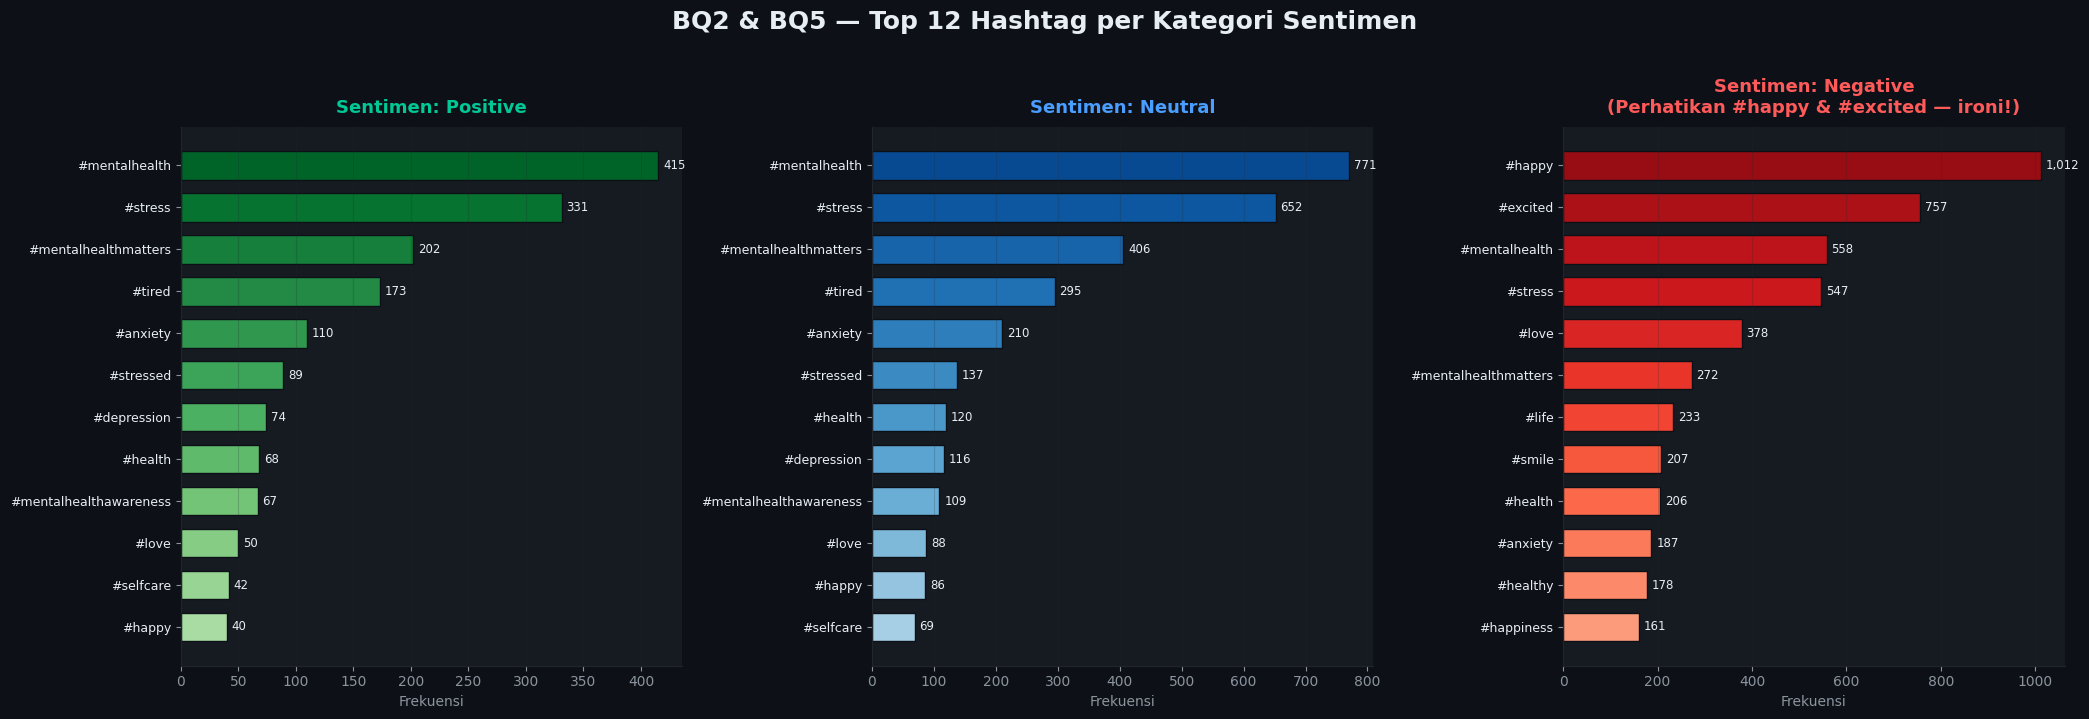

✅ Disimpan → figures\viz2_top_hashtags.png


In [25]:
# Viz 2 — Top 12 Hashtag per Sentimen (BQ2 & BQ5)
fig2, axes2 = plt.subplots(1, 3, figsize=(21, 7), facecolor=BG)
fig2.suptitle('BQ2 & BQ5 — Top 12 Hashtag per Kategori Sentimen',
              fontsize=18, fontweight='bold', color=TXT, y=1.02)
cmaps = {'Positive': plt.cm.Greens, 'Neutral': plt.cm.Blues, 'Negative': plt.cm.Reds}

for ax, sentiment in zip(axes2, ['Positive', 'Neutral', 'Negative']):
    ax.set_facecolor(CARD)
    data  = top_hashtags[sentiment][:12][::-1]
    tags  = [f'#{d[0]}' for d in data]
    freqs = [d[1] for d in data]
    n     = len(freqs)
    colors = [cmaps[sentiment](0.35 + 0.55 * (i / max(n - 1, 1))) for i in range(n)]
    bars  = ax.barh(tags, freqs, color=colors, edgecolor=BG, height=0.68)
    for bar in bars:
        ax.text(bar.get_width() + max(freqs) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8.5, color=TXT)
    title = f'Sentimen: {sentiment}'
    if sentiment == 'Negative':
        title += '\n(Perhatikan #happy & #excited — ironi!)'
    ax.set_title(title, fontsize=13, fontweight='bold', color=PAL[sentiment], pad=10)
    ax.set_xlabel('Frekuensi', color=SUB)
    ax.tick_params(axis='y', labelcolor=TXT, labelsize=9)
    ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
save_figure(fig2, 'viz2_top_hashtags')

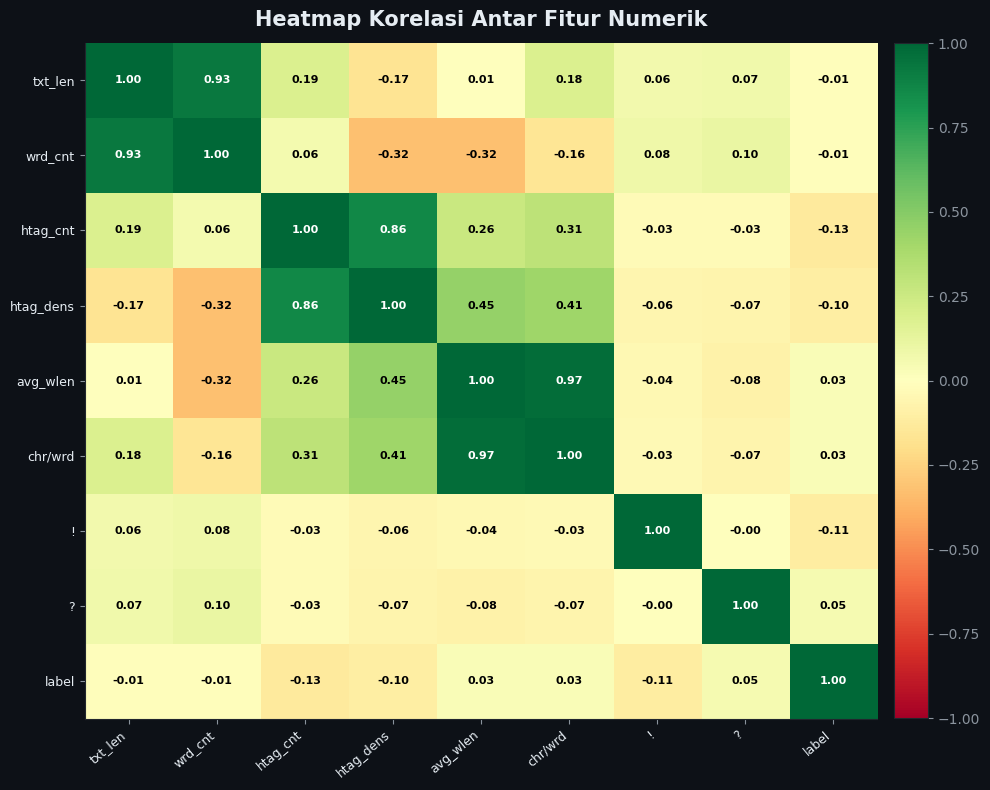

✅ Disimpan → figures\viz3_correlation_heatmap.png


In [26]:
# Viz 3 — Heatmap Korelasi Antar Fitur
numeric_cols = [
    'text_length_clean', 'word_count', 'hashtag_count', 'hashtag_density',
    'avg_word_len', 'char_per_word', 'exclaim_count', 'question_count', 'labels',
]
short_labels = ['txt_len', 'wrd_cnt', 'htag_cnt', 'htag_dens',
                'avg_wlen', 'chr/wrd', '!', '?', 'label']
corr_matrix = df[numeric_cols].corr().round(3)

fig3, ax3 = plt.subplots(figsize=(10, 8), facecolor=BG)
ax3.set_facecolor(CARD)
im = ax3.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax3.set_xticks(range(len(numeric_cols)))
ax3.set_yticks(range(len(numeric_cols)))
ax3.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=9, color=TXT)
ax3.set_yticklabels(short_labels, fontsize=9, color=TXT)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        v = corr_matrix.values[i, j]
        ax3.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, fontweight='bold',
                 color='black' if abs(v) < 0.5 else 'white')
plt.colorbar(im, ax=ax3, fraction=0.04, pad=0.02)
ax3.set_title('Heatmap Korelasi Antar Fitur Numerik', fontsize=15, fontweight='bold', color=TXT, pad=12)
plt.tight_layout()
save_figure(fig3, 'viz3_correlation_heatmap')

---
# BAGIAN 3 — A/B TESTING & EXPLANATORY ANALYSIS
> Uji Normalitas | Mann-Whitney U | Kruskal-Wallis | Section 7 Viz 4–5

In [27]:
# Uji Normalitas (Shapiro-Wilk) — sampel 200 per kelompok untuk efisiensi
SAMPLE_SIZE = 200
print(f'Uji Normalitas Shapiro-Wilk (n={SAMPLE_SIZE} per kelompok)\n')
for sentiment, group in [('Positive', pos), ('Neutral', neu), ('Negative', neg)]:
    sample = group['hashtag_count'].sample(min(SAMPLE_SIZE, len(group)), random_state=42)
    stat, p = shapiro(sample)
    print(f'  {sentiment:<10} stat={stat:.4f}  {is_significant(p)}')

Uji Normalitas Shapiro-Wilk (n=200 per kelompok)

  Positive   stat=0.6991  ✅ SIGNIFIKAN → Tolak H₀ (p=< 0.0001)
  Neutral    stat=0.7737  ✅ SIGNIFIKAN → Tolak H₀ (p=< 0.0001)
  Negative   stat=0.7933  ✅ SIGNIFIKAN → Tolak H₀ (p=< 0.0001)


In [28]:
# BQ3 — Mann-Whitney U Test: Hashtag Count (Positive vs Negative)
# H0: Tidak ada perbedaan hashtag count antara Positive dan Negative
u_ht, p_ht = mannwhitneyu(pos['hashtag_count'], neg['hashtag_count'], alternative='two-sided')

print('BQ3 — Hashtag Count: Positive vs Negative')
print(f'  Mean Positive : {pos["hashtag_count"].mean():.3f}')
print(f'  Mean Negative : {neg["hashtag_count"].mean():.3f}')
print(f'  U-statistic   : {u_ht:.2f}')
print(f'  Keputusan     : {is_significant(p_ht)}')

BQ3 — Hashtag Count: Positive vs Negative
  Mean Positive : 3.728
  Mean Negative : 5.247
  U-statistic   : 2713476.00
  Keputusan     : ✅ SIGNIFIKAN → Tolak H₀ (p=< 0.0001)


In [29]:
# BQ3 — Mann-Whitney U Test: Hashtag Density (Positive vs Negative)
# H0: Tidak ada perbedaan hashtag density antara Positive dan Negative
u_hd, p_hd = mannwhitneyu(pos['hashtag_density'], neg['hashtag_density'], alternative='two-sided')

print('BQ3 — Hashtag Density: Positive vs Negative')
print(f'  Mean Positive : {pos["hashtag_density"].mean():.4f}')
print(f'  Mean Negative : {neg["hashtag_density"].mean():.4f}')
print(f'  U-statistic   : {u_hd:.2f}')
print(f'  Keputusan     : {is_significant(p_hd)}')

BQ3 — Hashtag Density: Positive vs Negative
  Mean Positive : 0.1639
  Mean Negative : 0.2084
  U-statistic   : 2746330.50
  Keputusan     : ✅ SIGNIFIKAN → Tolak H₀ (p=< 0.0001)


In [30]:
# BQ4 — Kruskal-Wallis: Word Count & Text Length (semua sentimen)
# H0: Tidak ada perbedaan antar ketiga kelompok sentimen
h_wc, p_wc = kruskal(pos['word_count'], neu['word_count'], neg['word_count'])
h_tl, p_tl = kruskal(pos['text_length_clean'], neu['text_length_clean'], neg['text_length_clean'])

print('BQ4 — Word Count (Positive vs Neutral vs Negative)')
print(f'  H-statistic   : {h_wc:.4f}')
print(f'  Keputusan     : {is_significant(p_wc)}')
print()
print('BQ4 — Text Length (Positive vs Neutral vs Negative)')
print(f'  H-statistic   : {h_tl:.4f}')
print(f'  Keputusan     : {is_significant(p_tl)}')

BQ4 — Word Count (Positive vs Neutral vs Negative)
  H-statistic   : 1.8617
  Keputusan     :  Tidak Signifikan → Gagal Tolak H₀ (p=0.394225)

BQ4 — Text Length (Positive vs Neutral vs Negative)
  H-statistic   : 0.9495
  Keputusan     :  Tidak Signifikan → Gagal Tolak H₀ (p=0.622053)


In [31]:
# Simpan hasil uji statistik ke JSON
ab_results = {
    'hashtag_count_pos_neg': {
        'test': 'Mann-Whitney U', 'metric': 'Hashtag Count',
        'group_a': 'Positive', 'group_b': 'Negative',
        'mean_a': round(pos['hashtag_count'].mean(), 3),
        'mean_b': round(neg['hashtag_count'].mean(), 3),
        'statistic': round(u_ht, 2), 'pvalue': float(p_ht),
        'significant': bool(p_ht < ALPHA),
        'h0': 'Tidak ada perbedaan hashtag count antara Positive dan Negative',
    },
    'hashtag_density_pos_neg': {
        'test': 'Mann-Whitney U', 'metric': 'Hashtag Density',
        'group_a': 'Positive', 'group_b': 'Negative',
        'mean_a': round(pos['hashtag_density'].mean(), 4),
        'mean_b': round(neg['hashtag_density'].mean(), 4),
        'statistic': round(u_hd, 2), 'pvalue': float(p_hd),
        'significant': bool(p_hd < ALPHA),
        'h0': 'Tidak ada perbedaan hashtag density antara Positive dan Negative',
    },
    'word_count_all': {
        'test': 'Kruskal-Wallis', 'metric': 'Word Count',
        'groups': ['Positive', 'Neutral', 'Negative'],
        'means': [round(pos['word_count'].mean(), 3),
                  round(neu['word_count'].mean(), 3),
                  round(neg['word_count'].mean(), 3)],
        'statistic': round(h_wc, 4), 'pvalue': float(p_wc),
        'significant': bool(p_wc < ALPHA),
        'h0': 'Tidak ada perbedaan word count antar ketiga sentimen',
    },
    'text_length_all': {
        'test': 'Kruskal-Wallis', 'metric': 'Text Length',
        'groups': ['Positive', 'Neutral', 'Negative'],
        'means': [round(pos['text_length_clean'].mean(), 2),
                  round(neu['text_length_clean'].mean(), 2),
                  round(neg['text_length_clean'].mean(), 2)],
        'statistic': round(h_tl, 4), 'pvalue': float(p_tl),
        'significant': bool(p_tl < ALPHA),
        'h0': 'Tidak ada perbedaan text length antar ketiga sentimen',
    },
}
out_path = PROCESSED_DIR / 'ab_results.json'
with open(out_path, 'w') as f:
    json.dump(ab_results, f, indent=2)
print(f'Hasil A/B Testing disimpan → {out_path}')

Hasil A/B Testing disimpan → processed\ab_results.json


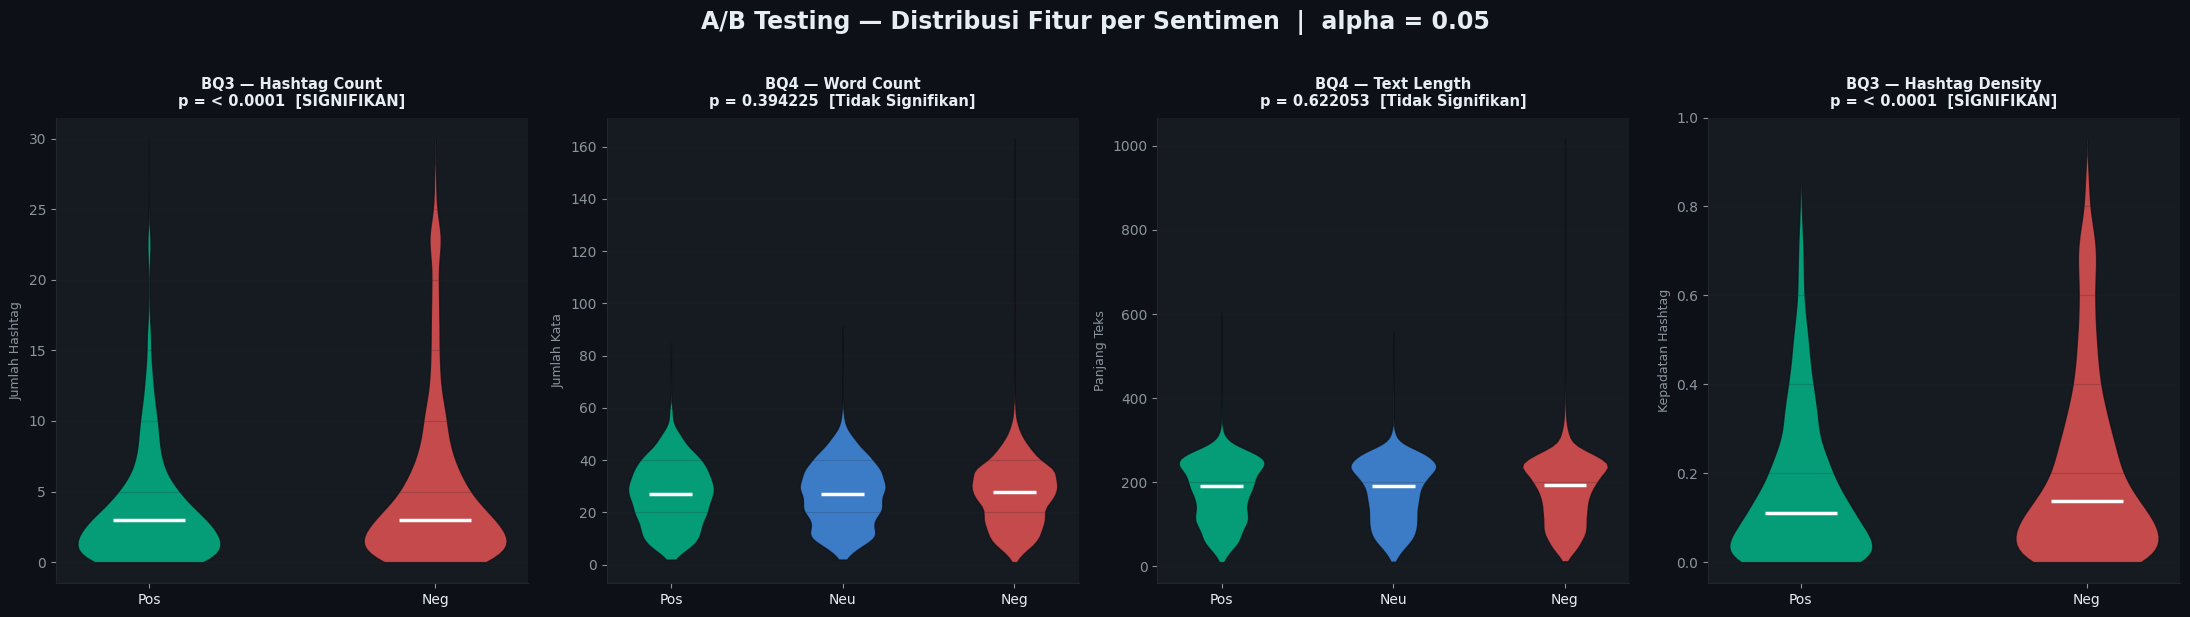

✅ Disimpan → figures\viz4_ab_testing.png


In [32]:
# Viz 4 — A/B Testing Violin Plot
tests_config = [
    ('hashtag_count',     'BQ3 — Hashtag Count',  'Jumlah Hashtag',    p_ht, ['Positive', 'Negative']),
    ('word_count',        'BQ4 — Word Count',      'Jumlah Kata',       p_wc, ['Positive', 'Neutral', 'Negative']),
    ('text_length_clean', 'BQ4 — Text Length',     'Panjang Teks',      p_tl, ['Positive', 'Neutral', 'Negative']),
    ('hashtag_density',   'BQ3 — Hashtag Density', 'Kepadatan Hashtag', p_hd, ['Positive', 'Negative']),
]
fig4, axes4 = plt.subplots(1, 4, figsize=(22, 6), facecolor=BG)
fig4.suptitle(f'A/B Testing — Distribusi Fitur per Sentimen  |  alpha = {ALPHA}',
              fontsize=17, fontweight='bold', color=TXT, y=1.02)

for ax, (col, title, ylabel, pval, groups) in zip(axes4, tests_config):
    ax.set_facecolor(CARD)
    data      = [df[df['label_text'] == s][col].values for s in groups]
    positions = list(range(1, len(groups) + 1))
    parts     = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    for body, sentiment in zip(parts['bodies'], groups):
        body.set_facecolor(PAL[sentiment]); body.set_alpha(0.75); body.set_edgecolor(BG)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2.5)
    ax.set_xticks(positions)
    ax.set_xticklabels([g[:3] for g in groups], color=TXT, fontsize=10)
    ax.set_ylabel(ylabel, color=SUB, fontsize=9)
    sig_label = 'SIGNIFIKAN' if pval < ALPHA else 'Tidak Signifikan'
    ax.set_title(f'{title}\np = {format_pvalue(pval)}  [{sig_label}]', fontsize=10.5, color=TXT, pad=8)
    ax.grid(axis='y', alpha=0.2, color=GRID_C)

plt.tight_layout()
save_figure(fig4, 'viz4_ab_testing')

### 7. Explanatory Analysis Jawaban Business Questions

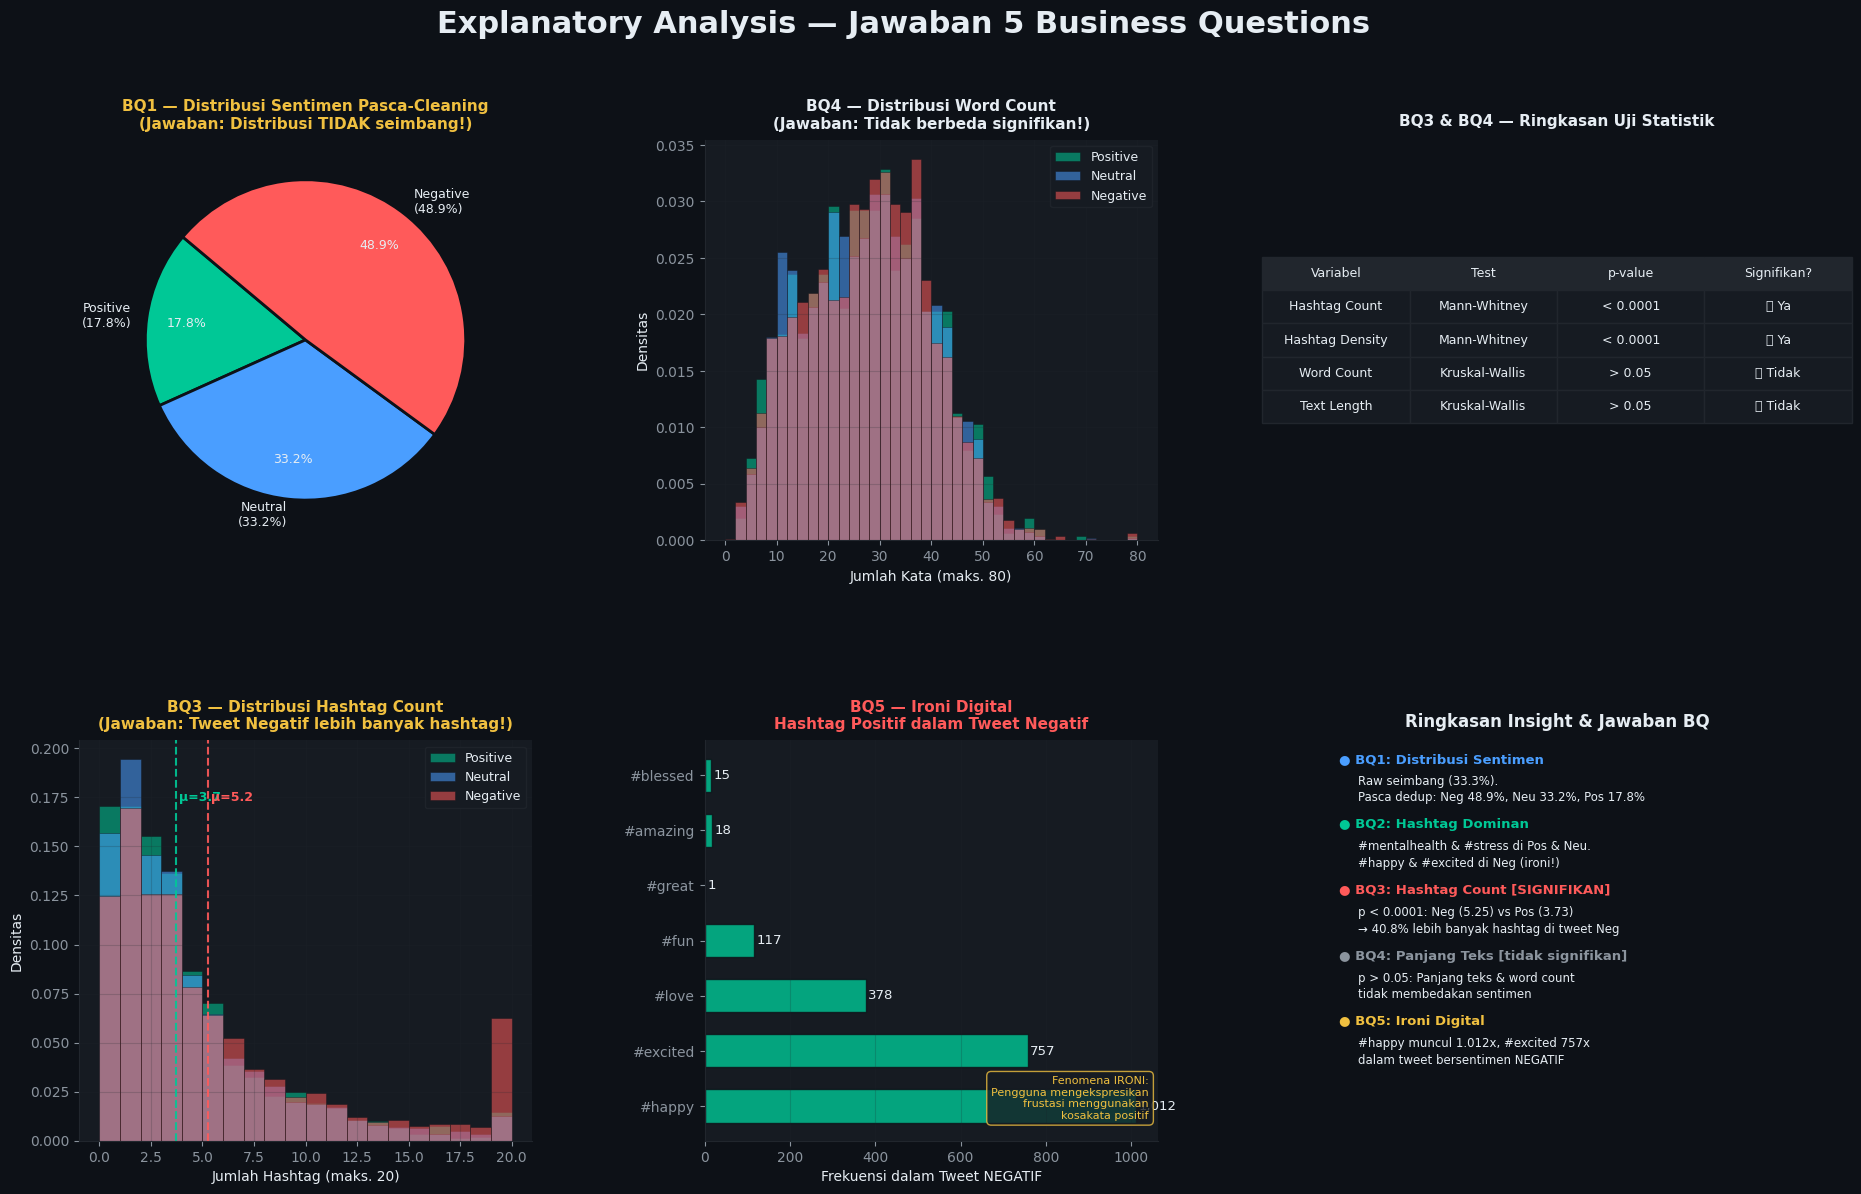

✅ Disimpan → figures\viz5_explanatory.png

✅ Semua proses selesai!
   Output tersimpan di folder: processed/ & figures/


In [34]:
# Viz 5 Explanatory Analysis Dashboard (2×3 grid)
YEL = THEME['YEL']

fig5 = plt.figure(figsize=(22, 13), facecolor=BG)
fig5.suptitle('Explanatory Analysis — Jawaban 5 Business Questions',
              fontsize=22, fontweight='bold', color=TXT, y=0.98)
gs5 = gridspec.GridSpec(2, 3, figure=fig5, hspace=0.5, wspace=0.38)

# 5A: Pie Chart Distribusi Sentimen (BQ1)
ax_5a  = fig5.add_subplot(gs5[0, 0])
sizes  = [len(pos), len(neu), len(neg)]
labels = ['Positive\n(17.8%)', 'Neutral\n(33.2%)', 'Negative\n(48.9%)']
ax_5a.pie(sizes, labels=labels, colors=list(PAL.values()),
          autopct='%1.1f%%', startangle=140,
          textprops={'color': TXT, 'fontsize': 9},
          wedgeprops={'edgecolor': BG, 'linewidth': 2}, pctdistance=0.75)
ax_5a.set_title('BQ1 — Distribusi Sentimen Pasca-Cleaning\n(Jawaban: Distribusi TIDAK seimbang!)',
                fontsize=11, fontweight='bold', pad=8, color=YEL)

# 5B: Word Count Distribution (BQ4)
ax_5b = fig5.add_subplot(gs5[0, 1])
for sentiment in ['Positive', 'Neutral', 'Negative']:
    vals = df[df['label_text'] == sentiment]['word_count'].clip(upper=80)
    ax_5b.hist(vals, bins=40, alpha=0.55, color=PAL[sentiment], label=sentiment,
               density=True, range=(0, 80), edgecolor=BG, linewidth=0.5)
ax_5b.set_xlabel('Jumlah Kata (maks. 80)')
ax_5b.set_ylabel('Densitas')
ax_5b.set_title('BQ4 — Distribusi Word Count\n(Jawaban: Tidak berbeda signifikan!)',
                fontsize=11, fontweight='bold', pad=8, color=TXT)
ax_5b.legend(fontsize=9); ax_5b.grid(alpha=0.2)

# 5C: Tabel Ringkasan Uji Statistik (BQ3 & BQ4)
ax_5c = fig5.add_subplot(gs5[0, 2])
ax_5c.axis('off')
table_data = [
    ['Variabel', 'Test', 'p-value', 'Signifikan?'],
    ['Hashtag Count',   'Mann-Whitney',   '< 0.0001', '\u2705 Ya'],
    ['Hashtag Density', 'Mann-Whitney',   '< 0.0001', '\u2705 Ya'],
    ['Word Count',      'Kruskal-Wallis', '> 0.05',   '\u274c Tidak'],
    ['Text Length',     'Kruskal-Wallis', '> 0.05',   '\u274c Tidak'],
]
table = ax_5c.table(cellText=table_data[1:], colLabels=table_data[0],
                    cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.3, 2.0)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(GRID_C)
    cell.set_facecolor(CARD if row > 0 else '#21262D')
    cell.set_text_props(color=TXT)
ax_5c.set_title('BQ3 & BQ4 — Ringkasan Uji Statistik', fontsize=11, fontweight='bold', pad=10)

# 5D: Distribusi Hashtag Count (BQ3)
ax_5d = fig5.add_subplot(gs5[1, 0])
for sentiment in ['Positive', 'Neutral', 'Negative']:
    vals = df[df['label_text'] == sentiment]['hashtag_count'].clip(upper=20)
    ax_5d.hist(vals, bins=20, alpha=0.55, color=PAL[sentiment], label=sentiment,
               density=True, range=(0, 20), edgecolor=BG, linewidth=0.5)
for sentiment in ['Positive', 'Negative']:
    mean_val = df[df['label_text'] == sentiment]['hashtag_count'].mean()
    ax_5d.axvline(mean_val, color=PAL[sentiment], linestyle='--', linewidth=1.5, alpha=0.9)
    ax_5d.text(mean_val + 0.15, ax_5d.get_ylim()[1] * 0.85,
               f'\u03bc={mean_val:.1f}', color=PAL[sentiment], fontsize=9, fontweight='bold')
ax_5d.set_xlabel('Jumlah Hashtag (maks. 20)')
ax_5d.set_ylabel('Densitas')
ax_5d.set_title('BQ3 — Distribusi Hashtag Count\n(Jawaban: Tweet Negatif lebih banyak hashtag!)',
                fontsize=11, fontweight='bold', pad=8, color=YEL)
ax_5d.legend(fontsize=9); ax_5d.grid(alpha=0.2)

# 5E: Ironi Digital — Hashtag positif dalam tweet negatif (BQ5)
ax_5e         = fig5.add_subplot(gs5[1, 1])
ironic_tags   = ['happy', 'excited', 'love', 'fun', 'great', 'amazing', 'blessed']
neg_tags_flat = [
    tag
    for tag_list in df[df['label_text'] == 'Negative']['hashtag_list']
    for tag in tag_list
]
neg_counter   = Counter(neg_tags_flat)
ironic_counts = {tag: neg_counter[tag] for tag in ironic_tags if tag in neg_counter}
if ironic_counts:
    tags_ir   = [f'#{tag}' for tag in ironic_counts]
    counts_ir = list(ironic_counts.values())
    bars_ir   = ax_5e.barh(tags_ir, counts_ir, color=PAL['Positive'], alpha=0.8, edgecolor=BG, height=0.6)
    for bar in bars_ir:
        ax_5e.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                   f'{int(bar.get_width()):,}', va='center', fontsize=9.5, color=TXT)
    ax_5e.set_xlabel('Frekuensi dalam Tweet NEGATIF')
    ax_5e.set_title('BQ5 — Ironi Digital\nHashtag Positif dalam Tweet Negatif',
                    fontsize=11, fontweight='bold', pad=8, color=PAL['Negative'])
    ax_5e.text(0.98, 0.05,
               'Fenomena IRONI:\nPengguna mengekspresikan\nfrustasi menggunakan\nkosakata positif',
               transform=ax_5e.transAxes, ha='right', va='bottom', fontsize=8, color=YEL,
               bbox=dict(boxstyle='round,pad=0.4', facecolor=CARD, edgecolor=YEL, alpha=0.8))
    ax_5e.grid(axis='x', alpha=0.2)

# 5F: Ringkasan Insight (BQ1–BQ5)
ax_5f = fig5.add_subplot(gs5[1, 2])
ax_5f.set_facecolor(CARD); ax_5f.axis('off')
insights = [
    ('BQ1', PAL['Neutral'],  'Distribusi Sentimen',
     'Raw seimbang (33.3%).\nPasca dedup: Neg 48.9%, Neu 33.2%, Pos 17.8%'),
    ('BQ2', PAL['Positive'], 'Hashtag Dominan',
     '#mentalhealth & #stress di Pos & Neu.\n#happy & #excited di Neg (ironi!)'),
    ('BQ3', PAL['Negative'], 'Hashtag Count [SIGNIFIKAN]',
     'p < 0.0001: Neg (5.25) vs Pos (3.73)\n\u2192 40.8% lebih banyak hashtag di tweet Neg'),
    ('BQ4', THEME['SUB'],    'Panjang Teks [tidak signifikan]',
     'p > 0.05: Panjang teks & word count\ntidak membedakan sentimen'),
    ('BQ5', THEME['YEL'],    'Ironi Digital',
     '#happy muncul 1.012x, #excited 757x\ndalam tweet bersentimen NEGATIF'),
]
y_pos = 0.97
for code, color, title, desc in insights:
    ax_5f.text(0.02, y_pos, f'\u25cf {code}: {title}',
               transform=ax_5f.transAxes, fontsize=9.5, fontweight='bold', color=color, va='top')
    y_pos -= 0.055
    for line in desc.split('\n'):
        ax_5f.text(0.06, y_pos, line, transform=ax_5f.transAxes,
                   fontsize=8.5, color=TXT, va='top')
        y_pos -= 0.042
    y_pos -= 0.025
ax_5f.set_title('Ringkasan Insight & Jawaban BQ', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
save_figure(fig5, 'viz5_explanatory')

print('\n\u2705 Semua proses selesai!')
print(f'   Output tersimpan di folder: processed/ & figures/')